# STEP 4: Regularized Regression (Ridge & Lasso)
### SpaceFund Realty (SFR) Aerospace Ratings Engine — Capstone Project

**Owner:** Ornella Meffovoung Ngnitedem (R)  —  Sikiru Mustapha (C)

---
**Pipeline position:** `... → VIF Pruning → Regularization → XGBoost/SHAP`
Reads `train_no_outliers.csv`, `val_clean.csv`, `test_clean.csv`, `vif_pruning_log.csv` (Steps 1–3). Produces `ridge_lasso_model.json` for Step 5 / deployment.

## 4.1 — Mount Drive & Load All Required Files

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

PROJECT_FOLDER = "/content/drive/MyDrive/Gamma_Group_1"

train = pd.read_csv(f"{PROJECT_FOLDER}/train_no_outliers.csv")
val = pd.read_csv(f"{PROJECT_FOLDER}/val_clean.csv")
test = pd.read_csv(f"{PROJECT_FOLDER}/test_clean.csv")
vif_log = pd.read_csv(f"{PROJECT_FOLDER}/vif_pruning_log.csv")

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")
print(f"VIF-pruned features (from Step 3): {vif_log['feature_removed'].tolist()}")

Mounted at /content/drive
Train: (140, 32), Val: (18, 28), Test: (10, 28)
VIF-pruned features (from Step 3): ['OA_Lunar', 'Funding_Type_Public', 'Funding_Type_Unknown', 'TT_Rocket', 'OA_Suborbital']


## 4.2 — Rebuild Leakage-Free Design Matrices (Train / Val / Test)


In [2]:
continuous_cols = ["Payload (kg)", "Launch Cost ($M)", "Price ($/kg)", "Funding_num"]
train_skew = train[continuous_cols].skew()
log_decision = {col: abs(train_skew[col]) > 1 for col in continuous_cols}
print("Log-transform decisions (learned from train only):", log_decision)

def build_design_matrix(df, reference_dummy_cols=None, reference_multihot_cols=None):
    """
    Builds the numeric design matrix for any split (train/val/test).
    reference_dummy_cols / reference_multihot_cols: pass the TRAINING set's
    column lists here for val/test, so they get identical columns even if
    a category is missing or different in that split (leakage-free alignment).
    """
    df = df.copy()
    for col, do_log in log_decision.items():
        if do_log:
            df[f"log_{col}"] = np.log1p(df[col])
    log_cols = [f"log_{c}" for c, flag in log_decision.items() if flag]

    dummies = pd.get_dummies(df[["Country_Grouped", "Funding_Type"]], drop_first=True, dtype=int)
    if reference_dummy_cols is not None:
        # Align val/test to the exact same dummy columns seen in training
        dummies = dummies.reindex(columns=reference_dummy_cols, fill_value=0)

    multihot_cols = reference_multihot_cols or [c for c in df.columns if c.startswith(("LC_", "OA_", "TT_"))]
    X = pd.concat([df[log_cols], dummies, df[multihot_cols], df[["Funding_Missing"]]], axis=1).astype(float)
    return X, (dummies.columns.tolist() if reference_dummy_cols is None else reference_dummy_cols), multihot_cols

X_train_full, dummy_ref_cols, multihot_ref_cols = build_design_matrix(train)
X_val_full, _, _ = build_design_matrix(val, dummy_ref_cols, multihot_ref_cols)
X_test_full, _, _ = build_design_matrix(test, dummy_ref_cols, multihot_ref_cols)

# The pruned set = full set minus whatever Step 3's VIF loop removed
removed_features = vif_log["feature_removed"].tolist()
pruned_cols = [c for c in X_train_full.columns if c not in removed_features]
X_train_pruned = X_train_full[pruned_cols]
X_val_pruned = X_val_full[pruned_cols]
X_test_pruned = X_test_full[pruned_cols]

y_train = train["SFR"].astype(float).values
y_val = val["SFR"].astype(float).values
y_test = test["SFR"].astype(float).values

print(f"Full feature set: {X_train_full.shape[1]} predictors")
print(f"Pruned feature set: {X_train_pruned.shape[1]} predictors")
print(f"Columns identical across train/val/test: {list(X_train_full.columns) == list(X_val_full.columns) == list(X_test_full.columns)}")

Log-transform decisions (learned from train only): {'Payload (kg)': np.True_, 'Launch Cost ($M)': np.True_, 'Price ($/kg)': np.True_, 'Funding_num': np.True_}
Full feature set: 24 predictors
Pruned feature set: 19 predictors
Columns identical across train/val/test: True


## 4.3 — Tune Ridge & Lasso Penalty (α) on the Validation Set


In [3]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

alphas = np.logspace(-3, 3, 50)  # wide search: 0.001 to 1000

def tune_alpha(model_class, X_train, X_val, y_train, y_val):
    """
    Scans the alpha grid, fits on (scaled) training data, scores on validation.
    Returns the full results table and the best row (lowest validation RMSE).
    """
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    records = []
    for a in alphas:
        model = model_class(alpha=a, max_iter=20000) if model_class is Lasso else model_class(alpha=a)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_val_scaled)
        rmse = mean_squared_error(y_val, pred) ** 0.5
        r2 = r2_score(y_val, pred)
        records.append({"alpha": a, "val_rmse": rmse, "val_r2": r2})

    results_df = pd.DataFrame(records)
    best_row = results_df.loc[results_df["val_rmse"].idxmin()]
    return results_df, best_row, scaler

candidates = {
    "Ridge-Full":   (Ridge, X_train_full,   X_val_full),
    "Ridge-Pruned": (Ridge, X_train_pruned, X_val_pruned),
    "Lasso-Full":   (Lasso, X_train_full,   X_val_full),
    "Lasso-Pruned": (Lasso, X_train_pruned, X_val_pruned),
}

tuning_results = {}
for name, (model_class, Xtr, Xv) in candidates.items():
    results_df, best_row, scaler = tune_alpha(model_class, Xtr, Xv, y_train, y_val)
    tuning_results[name] = {"results_df": results_df, "best": best_row, "scaler": scaler,
                             "model_class": model_class, "X_train": Xtr, "X_val": Xv}
    print(f"{name:15s} -> best alpha={best_row['alpha']:.4f}, val RMSE={best_row['val_rmse']:.4f}, val R²={best_row['val_r2']:.4f}")

Ridge-Full      -> best alpha=44.9843, val RMSE=1.4557, val R²=0.6648
Ridge-Pruned    -> best alpha=33.9322, val RMSE=1.7158, val R²=0.5343
Lasso-Full      -> best alpha=0.0391, val RMSE=1.4664, val R²=0.6598
Lasso-Pruned    -> best alpha=0.0518, val RMSE=1.7789, val R²=0.4994


## 4.4 — Visualize the Alpha Search (Validation Curves)


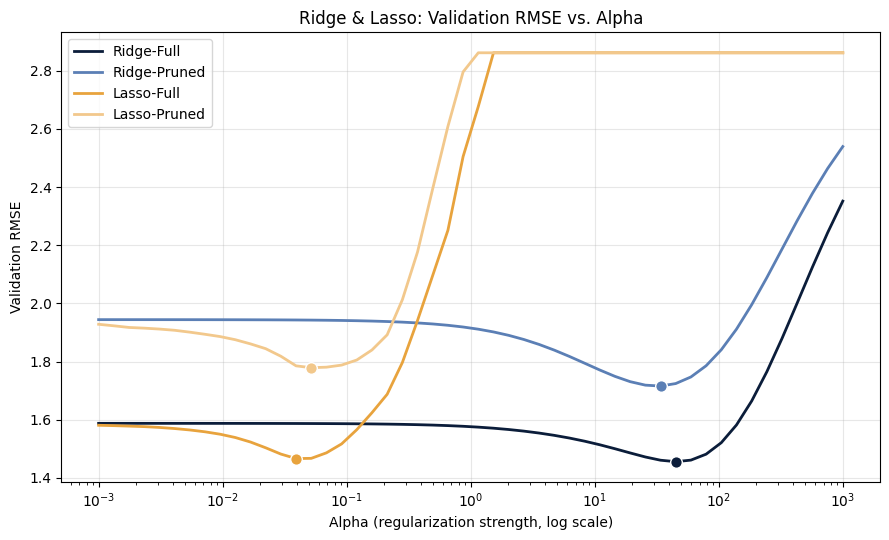

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {"Ridge-Full": "#0B1D3A", "Ridge-Pruned": "#5B7FB5", "Lasso-Full": "#E8A33D", "Lasso-Pruned": "#F2C88C"}

for name, data in tuning_results.items():
    df = data["results_df"]
    ax.plot(df["alpha"], df["val_rmse"], label=name, color=colors[name], linewidth=2)
    best = data["best"]
    ax.scatter([best["alpha"]], [best["val_rmse"]], color=colors[name], s=70, zorder=5, edgecolor="white")

ax.set_xscale("log")
ax.set_xlabel("Alpha (regularization strength, log scale)")
ax.set_ylabel("Validation RMSE")
ax.set_title("Ridge & Lasso: Validation RMSE vs. Alpha")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step4_alpha_validation_curve.png", dpi=150)
plt.show()

## 4.5 — Compare All 4 Candidates & Pick the Winner


          model    val_r2  val_rmse      alpha
0    Ridge-Full  0.664778  1.455656  44.984327
1    Lasso-Full  0.659813  1.466397   0.039069
2  Ridge-Pruned  0.534260  1.715791  33.932218
3  Lasso-Pruned  0.499391  1.778861   0.051795


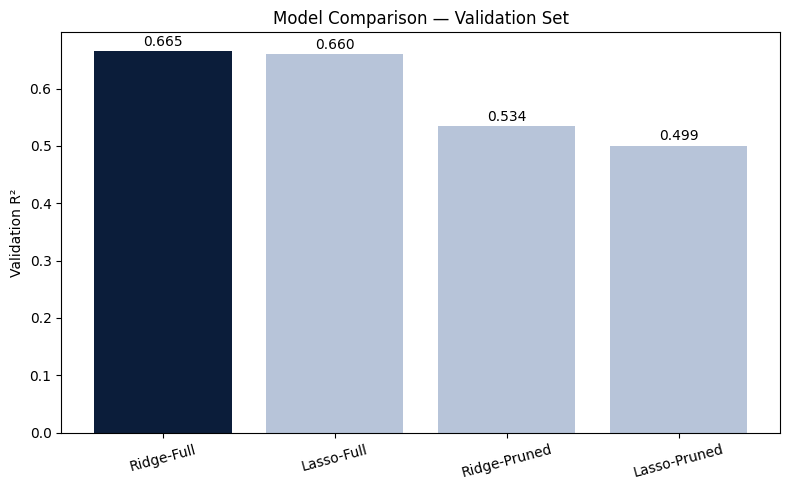


Winner (best validation R²): Ridge-Full


In [5]:
comparison_df = pd.DataFrame([
    {"model": name, "val_r2": data["best"]["val_r2"], "val_rmse": data["best"]["val_rmse"], "alpha": data["best"]["alpha"]}
    for name, data in tuning_results.items()
]).sort_values("val_r2", ascending=False).reset_index(drop=True)

print(comparison_df.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(comparison_df["model"], comparison_df["val_r2"],
              color=["#0B1D3A" if i == 0 else "#B7C4D9" for i in range(len(comparison_df))])
ax.set_ylabel("Validation R²")
ax.set_title("Model Comparison — Validation Set")
for bar, val in zip(bars, comparison_df["val_r2"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center", fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step4_model_comparison.png", dpi=150)
plt.show()

winner_name = comparison_df.iloc[0]["model"]
print(f"\nWinner (best validation R²): {winner_name}")

## 4.6 — Final Fit & Test Set Evaluation


In [6]:
winner_class = tuning_results[winner_name]["model_class"]
winner_alpha = tuning_results[winner_name]["best"]["alpha"]
is_pruned = "Pruned" in winner_name

X_train_final = X_train_pruned if is_pruned else X_train_full
X_val_final = X_val_pruned if is_pruned else X_val_full
X_test_final = X_test_pruned if is_pruned else X_test_full

X_trainval = pd.concat([X_train_final, X_val_final], axis=0).reset_index(drop=True)
y_trainval = np.concatenate([y_train, y_val])

final_scaler = StandardScaler().fit(X_trainval)
X_trainval_scaled = final_scaler.transform(X_trainval)
X_test_scaled = final_scaler.transform(X_test_final)

final_model = winner_class(alpha=winner_alpha, max_iter=20000) if winner_class is Lasso else winner_class(alpha=winner_alpha)
final_model.fit(X_trainval_scaled, y_trainval)

test_pred = final_model.predict(X_test_scaled)
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
test_r2 = r2_score(y_test, test_pred)

print(f"FINAL MODEL: {winner_name} (alpha={winner_alpha:.4f})")
print(f"TEST SET  -> RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")

FINAL MODEL: Ridge-Full (alpha=44.9843)
TEST SET  -> RMSE: 1.6087, R²: 0.5023


## 4.7 — Visualize Test Predictions


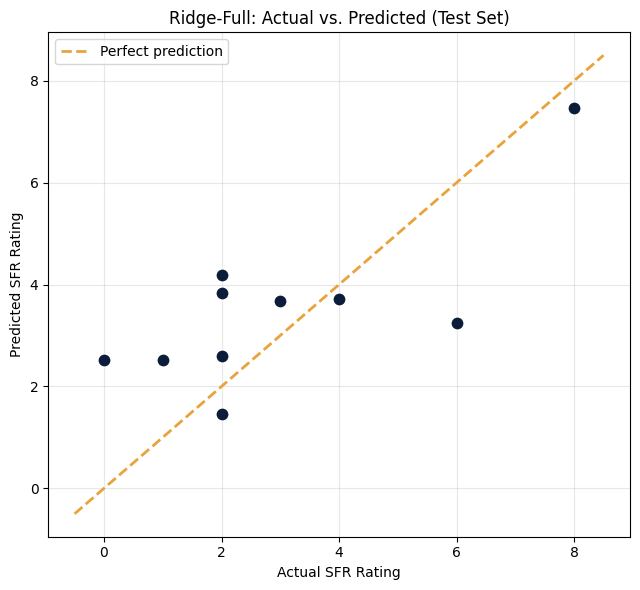

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, test_pred, color="#0B1D3A", s=90, edgecolor="white", zorder=3)
lims = [min(y_test.min(), test_pred.min()) - 0.5, max(y_test.max(), test_pred.max()) + 0.5]
ax.plot(lims, lims, "--", color="#E8A33D", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual SFR Rating")
ax.set_ylabel("Predicted SFR Rating")
ax.set_title(f"{winner_name}: Actual vs. Predicted (Test Set)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step4_actual_vs_predicted.png", dpi=150)
plt.show()

## 4.8 — Coefficient Importance


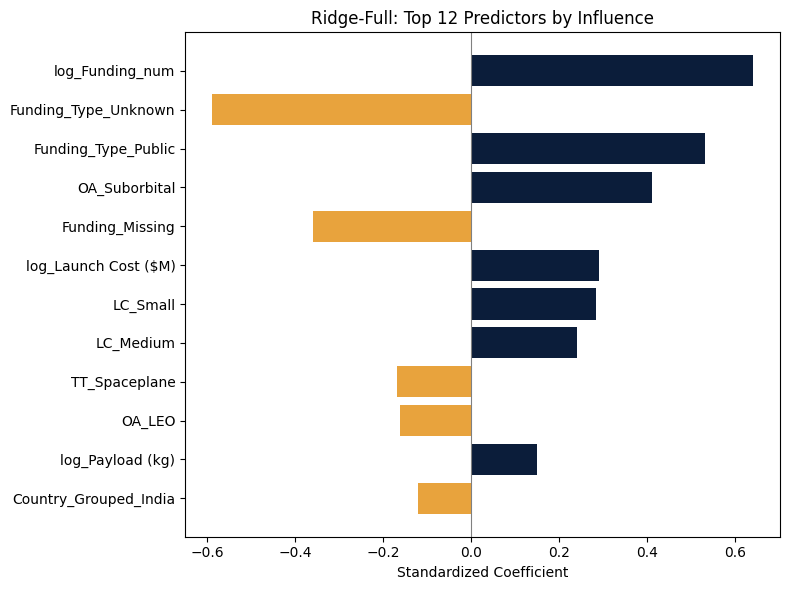

              feature  coefficient
      log_Funding_num     0.640233
 Funding_Type_Unknown    -0.588390
  Funding_Type_Public     0.532315
        OA_Suborbital     0.409803
      Funding_Missing    -0.359869
 log_Launch Cost ($M)     0.290120
             LC_Small     0.282888
            LC_Medium     0.240920
        TT_Spaceplane    -0.167575
               OA_LEO    -0.162753
     log_Payload (kg)     0.149453
Country_Grouped_India    -0.121956


In [8]:
coef_df = pd.DataFrame({
    "feature": X_trainval.columns,
    "coefficient": final_model.coef_,
}).sort_values("coefficient", key=abs, ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 6))
colors_bar = ["#0B1D3A" if c > 0 else "#E8A33D" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"][::-1], coef_df["coefficient"][::-1], color=colors_bar[::-1])
ax.set_xlabel("Standardized Coefficient")
ax.set_title(f"{winner_name}: Top 12 Predictors by Influence")
ax.axvline(0, color="grey", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step4_coefficients.png", dpi=150)
plt.show()

print(coef_df.to_string(index=False))

## 4.9 — Save the Final Model for Step 5 & Deployment


In [9]:
import json

model_artifact = {
    "model_name": winner_name,
    "alpha": float(winner_alpha),
    "feature_names": list(X_trainval.columns),
    "scaler_mean": final_scaler.mean_.tolist(),
    "scaler_scale": final_scaler.scale_.tolist(),
    "coefficients": final_model.coef_.tolist(),
    "intercept": float(final_model.intercept_),
    "test_rmse": float(test_rmse),
    "test_r2": float(test_r2),
    "log_transform_columns": [c for c, flag in log_decision.items() if flag],
    "dummy_reference_columns": dummy_ref_cols,
    "multihot_reference_columns": multihot_ref_cols,
}

with open(f"{PROJECT_FOLDER}/ridge_lasso_model.json", "w") as f:
    json.dump(model_artifact, f, indent=2)

print(f"Saved to Google Drive folder: {PROJECT_FOLDER}")
print("  - ridge_lasso_model.json  (full model artifact for Step 5 comparison + deployment)")
print("  - step4_alpha_validation_curve.png")
print("  - step4_model_comparison.png")
print("  - step4_actual_vs_predicted.png")
print("  - step4_coefficients.png")
print(f"\nStep 4 complete: {winner_name} selected, test R² = {test_r2:.4f}")

Saved to Google Drive folder: /content/drive/MyDrive/Gamma_Group_1
  - ridge_lasso_model.json  (full model artifact for Step 5 comparison + deployment)
  - step4_alpha_validation_curve.png
  - step4_model_comparison.png
  - step4_actual_vs_predicted.png
  - step4_coefficients.png

Step 4 complete: Ridge-Full selected, test R² = 0.5023
